In [1]:
#ENVIROMENT
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.spatial import cKDTree

from IPython.display import display, Markdown

from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, learning_curve
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

RANDOM_STATE = 42
TARGET = "winter_snowfall"


RUN_HYPERPARAMETER_SEARCH = True
N_ITER_SEARCH = 25
CV_SPLITS = 5


TUNE_SAMPLE_SIZE = None


DIAGNOSTIC_SAMPLE_SIZE = 5_000
SHAP_SAMPLE_SIZE = 2_000

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except Exception:
    XGBRegressor = None
    XGBOOST_AVAILABLE = False

try:
    import shap
    SHAP_AVAILABLE = True
except Exception:
    shap = None
    SHAP_AVAILABLE = False

print("XGBoost available:", XGBOOST_AVAILABLE)
print("SHAP available:", SHAP_AVAILABLE)

XGBoost available: True
SHAP available: True


# Seasonal Snowfall Prediction in the European Alps  
## A Machine Learning Investigation Using ERA5-Land Climate Reanalysis and Topographic Data

**Project type:** Technical report + reproducible Jupyter notebook  
**Main task:** Predict winter snowfall from autumn climate variables and geographic/topographic features.  
**Target variable:** `winter_snowfall`  
**Prediction setting:** September–November predictors → following winter snowfall  
**Study area:** European Alps, approximately 43°N–48°N and 5°E–16°E  
**Temporal period:** 2000–2025 for the climate dataset. The elevation dataset is static, not yearly.

---

## 0. Executive Summary

Seasonal snowfall prediction is a useful machine-learning problem because snowfall is controlled by both **physical climate mechanisms** and **nonlinear statistical relationships**. In the European Alps, winter snowfall is affected by autumn temperature, autumn precipitation, elevation, latitude, longitude, and interactions between these variables. A small warming around the freezing threshold can strongly change whether precipitation reaches the ground as snow or rain.

This notebook improves the first version of the project by adding:

1. a stronger mathematical explanation of each model;
2. formal hypotheses instead of only metric definitions;
3. academic citations for the main algorithms;
4. inverse-distance weighted elevation imputation instead of deleting the full 18% of rows affected by missing DEM values;
5. a stronger hyperparameter search using 5-fold temporal cross-validation;
6. train/test metrics, residual diagnostics, Q–Q diagnostics, partial dependence plots, permutation importance, and optional SHAP explanations;
7. a full Discussion and a stronger final Conclusion.

The central research question is:

> **To what extent can winter snowfall in the European Alps be predicted using autumn climate conditions and geographic characteristics?**

The project compares statistical baselines, regularised linear models, Random Forests, and gradient boosting models. The final interpretation focuses not only on predictive accuracy, but also on which variables explain Alpine snowfall variability.

---
## 1. Introduction

### 1.1 Motivation

Seasonal snowfall is important in mountain regions because it influences freshwater storage, spring and summer river discharge, hydropower production, avalanche hazard, ecosystems, agriculture, and winter tourism. The Alps are particularly sensitive because large parts of the terrain lie close to the rain–snow transition zone. When air temperature rises slightly, the same precipitation event may produce rain instead of snow at lower and middle elevations.

Snow is also spatially complex. A grid cell at 2000 m can behave very differently from a grid cell at 500 m, even if both have similar large-scale weather. This is why this project combines **climate variables** from reanalysis with **topographic elevation** from a DEM.

### 1.2 Research Question

The main research question is:

> **Can winter snowfall in the European Alps be predicted from autumn temperature, autumn precipitation, and elevation?**

More specifically:

1. Can September–November temperature predict winter snowfall?
2. Does autumn precipitation provide predictive information about winter snow accumulation?
3. How important is elevation compared with climate variables?
4. Do nonlinear machine-learning models outperform linear statistical baselines?
5. Which features contribute most to snowfall variability?

### 1.3 Objectives

The objectives are:

1. load and validate the ERA5-Land-style climate dataset and the elevation dataset;
2. merge climate and elevation data by grid cell;
3. correct missing elevation values with inverse-distance weighted imputation;
4. develop physically meaningful features such as autumn mean temperature, autumn precipitation total, coldness indices, and elevation interactions;
5. compare Linear Regression, Ridge, Lasso, Random Forest, and gradient boosting;
6. tune nonlinear models using temporal cross-validation;
7. interpret model behaviour using feature importance, partial dependence, and SHAP where available;
8. discuss predictive performance, physical interpretation, limitations, and future improvements.

### 1.4 Assumptions and Constraints

This project uses several explicit assumptions:

- **Temporal generalisation:** relationships learned from 2000–2020 are assumed to remain useful for 2021–2025.
- **Grid-cell representation:** each ERA5 grid cell is treated as one observation for one year.
- **Static topography:** elevation is treated as fixed through time; it has no year range.
- **Reanalysis as proxy:** ERA5-Land-style variables are treated as physically consistent estimates of climate conditions, not as direct station observations.
- **Seasonal aggregation:** the problem is seasonal, not daily. Short weather events are not modelled directly.
- **Spatial dependence:** nearby grid cells are not perfectly independent. This is a known limitation because the train/test split is temporal, not spatial.

---
## Section 2 — Literature Review

### 2.1 Snowfall Formation

Snowfall forms when atmospheric moisture condenses and freezes into ice crystals, and when the vertical temperature profile allows solid precipitation to reach the surface. Near-surface air temperature is therefore a strong control on whether precipitation falls as rain or snow. In this project, monthly autumn temperature variables are used as predictors because they provide information about seasonal thermal state before winter.

### 2.2 Orographic Precipitation

Mountains force air masses to rise. Rising air cools, reaches saturation, and can produce enhanced precipitation on windward slopes. This process is known as **orographic precipitation**. Studies of mountain precipitation emphasize that terrain lifting can favor condensation and cloud formation, creating strong spatial gradients in precipitation across mountain ranges. Source: Napoli et al. (2019), *Variability of orographic enhancement of precipitation in the Alpine region*, https://pmc.ncbi.nlm.nih.gov/articles/PMC6746858/

### 2.3 Elevation Effects

Elevation affects snowfall through temperature lapse rates and exposure to orographic precipitation. ERA5-Land itself applies an elevation correction to the thermodynamic near-surface state, which shows why elevation is physically important for land-surface climate analysis. Source: Muñoz-Sabater et al. (2021), *ERA5-Land: a state-of-the-art global reanalysis dataset for land applications*, https://essd.copernicus.org/articles/13/4349/2021/

### 2.4 Machine Learning in Climate Science

Machine learning is increasingly used in weather and climate because it can model nonlinear relationships and interactions that are difficult to represent with simple linear equations. Tree-based ensembles are useful for tabular environmental data because they can learn thresholds and variable interactions without requiring explicit polynomial terms.

Useful method references:

- Random Forest Regressor, scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html
- Ridge regression, scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html
- Lasso regression, scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html
- XGBoost documentation: https://xgboost.readthedocs.io/en/stable/
- SHAP documentation: https://shap.readthedocs.io/en/latest/

---
## 3. Data Collection

### 3.1 ERA5-Land Climate Dataset

The climate dataset contains yearly grid-cell observations for the European Alps. The project uses autumn variables to predict winter snowfall.

| Column | Meaning | Role |
|---|---|---|
| `lat` | Latitude of grid cell | geographic predictor |
| `lon` | Longitude of grid cell | geographic predictor |
| `sep_temp`, `oct_temp`, `nov_temp` | Monthly autumn temperature | climate predictors |
| `sep_precip`, `oct_precip`, `nov_precip` | Monthly autumn precipitation | climate predictors |
| `winter_snowfall` | Winter snowfall | target |
| `year` | Year of observation | temporal split |

ERA5-Land is appropriate for this kind of problem because it provides physically consistent land-surface reanalysis fields over multiple decades. The official Copernicus Climate Data Store describes ERA5-Land as a reanalysis dataset that provides a consistent view of land variables over several decades.

### 3.2 Elevation Dataset

The elevation dataset contains one elevation value for each ERA5 grid cell. It is derived from a DEM and has columns:

| Column | Meaning |
|---|---|
| `lat` | Latitude of grid cell |
| `lon` | Longitude of grid cell |
| `elevation` | Elevation in meters |

A DEM is static topographic information. It does **not** have the same year range as ERA5-Land. For this project, it is attached to every climate year for the same grid cell.

### 3.3 Reproducible Data Loading Strategy

I have used a revised method for data loading so that it can run both locally and from the repo without any mishaps.

In [2]:
# Data loading

def find_data_file(filename: str) -> Path:
    """Find a data file in common project locations.

    Parameters
    ----------
    filename : str
        File name to search for, for example 'alps_snowfall_ml_dataset.csv'.

    Returns
    -------
    pathlib.Path
        Existing path to the requested file.

    Raises
    ------
    FileNotFoundError
        If the file cannot be found in any expected location.
    """
    cwd = Path.cwd()
    candidates = [
        cwd / "datasets" / filename,
        cwd / filename,
        cwd.parent / "datasets" / filename,
        cwd.parent / filename,
        cwd / "data_raw" / filename,
        cwd.parent / "data_raw" / filename,
        Path("/mnt/data") / filename,
    ]
    for path in candidates:
        if path.exists():
            return path
    msg = "Could not find {0}. Tried:\n".format(filename) + "\n".join(str(p) for p in candidates)
    raise FileNotFoundError(msg)

climate_path = find_data_file("alps_snowfall_ml_dataset.csv")
elevation_path = find_data_file("alps_elevation.csv")

climate = pd.read_csv(climate_path)
elevation = pd.read_csv(elevation_path)

print("Climate path:", climate_path)
print("Elevation path:", elevation_path)
print("Climate shape:", climate.shape)
print("Elevation shape:", elevation.shape)

display(climate.head())
display(elevation.head())

Climate path: C:\Users\Teo\anaconda_projects\snowfall\datasets\alps_snowfall_ml_dataset.csv
Elevation path: C:\Users\Teo\anaconda_projects\snowfall\datasets\alps_elevation.csv
Climate shape: (147186, 10)
Elevation shape: (5661, 3)


,lat,lon,sep_temp,oct_temp,nov_temp,sep_precip,oct_precip,nov_precip,winter_snowfall,year
0,48.0,5.0,13.720734,9.956451,6.689029,0.093543,0.118970,0.161477,0.022422,2000
1,48.0,5.1,13.533885,9.793838,6.473730,0.096865,0.119708,0.168315,0.023954,2000
2,48.0,5.2,13.359926,9.584475,6.221841,0.098739,0.120086,0.173524,0.024710,2000
3,48.0,5.3,13.320474,9.519834,6.112857,0.096361,0.119496,0.174590,0.023715,2000
4,48.0,5.4,13.381606,9.522227,6.059016,0.092295,0.118310,0.173335,0.021996,2000


,lat,lon,elevation
0,48.0,5.0,312.920105
1,48.0,5.1,353.805573
2,48.0,5.2,402.360992
3,48.0,5.3,380.785126
4,48.0,5.4,462.431274


### 3.5 Data Processing Pipeline

The processing pipeline is:

1. standardise latitude and longitude keys;
2. inspect missing DEM values;
3. impute missing elevation values at the grid-cell level using inverse-distance weighting;
4. merge climate and elevation data;
5. engineer machine-learning features;
6. split by year so that future years are never used to predict past years.

The important methodological change is that missing elevation values are **not dropped**. Instead, they are estimated from nearby valid DEM cells. This preserves the observations that were previously removed from the dataset.

In [3]:
# ── 3.6 ELEVATION IMPUTATION AND CLIMATE + DEM MERGE ──────────────────────

def coordinate_key(df: pd.DataFrame, decimals: int = 4) -> pd.DataFrame:
    """Create stable string keys for latitude and longitude."""
    out = df.copy()
    out["lat_key"] = out["lat"].astype(float).round(decimals).map(lambda x: f"{x:.{decimals}f}")
    out["lon_key"] = out["lon"].astype(float).round(decimals).map(lambda x: f"{x:.{decimals}f}")
    return out


def idw_impute_elevation(elev_df: pd.DataFrame, k: int = 5, power: float = 2.0) -> pd.DataFrame:
    """Impute missing elevation values with inverse-distance weighting.

    Missing elevation at a grid cell is estimated from the k nearest valid grid cells:

        z_hat(x) = sum_i w_i z_i / sum_i w_i,  where  w_i = 1 / d_i^p

    This is a deterministic spatial interpolation method. It is appropriate here because
    elevation changes smoothly over space at the coarse ERA5 grid scale, although it can
    still underrepresent sharp mountain ridges and valleys.
    """
    out = elev_df.copy()
    out["elevation_was_imputed"] = out["elevation"].isna()

    valid = out.dropna(subset=["elevation"])
    missing = out[out["elevation"].isna()]

    if missing.empty:
        return out

    tree = cKDTree(valid[["lat", "lon"]].to_numpy(float))
    distances, indices = tree.query(missing[["lat", "lon"]].to_numpy(float), k=k)

    # Make dimensions consistent when k=1.
    distances = np.atleast_2d(distances)
    indices = np.atleast_2d(indices)
    if distances.shape[0] != len(missing):
        distances = distances.T
        indices = indices.T

    neighbour_values = valid.iloc[indices.ravel()]["elevation"].to_numpy().reshape(indices.shape)
    safe_distances = np.where(distances == 0, 1e-12, distances)
    weights = 1 / (safe_distances ** power)
    imputed_values = (weights * neighbour_values).sum(axis=1) / weights.sum(axis=1)

    out.loc[missing.index, "elevation"] = imputed_values
    return out

# Create robust coordinate keys.
climate_keyed = coordinate_key(climate)
elevation_keyed = coordinate_key(elevation)

original_missing_elev_cells = elevation_keyed["elevation"].isna().sum()
elevation_clean = idw_impute_elevation(elevation_keyed, k=5, power=2.0)

print("Original missing elevation cells:", original_missing_elev_cells)
print("Remaining missing elevation cells after IDW:", elevation_clean["elevation"].isna().sum())
print("Imputed elevation cells:", elevation_clean["elevation_was_imputed"].sum())

# Merge climate observations with the cleaned elevation grid.
data = climate_keyed.merge(
    elevation_clean[["lat_key", "lon_key", "elevation", "elevation_was_imputed"]],
    on=["lat_key", "lon_key"],
    how="left",
    validate="many_to_one"
).drop(columns=["lat_key", "lon_key"])

print("Merged shape:", data.shape)
print("Rows missing elevation after merge:", data["elevation"].isna().sum())
display(data.head())

Original missing elevation cells: 1033
Remaining missing elevation cells after IDW: 0
Imputed elevation cells: 1033
Merged shape: (147186, 12)
Rows missing elevation after merge: 0


,lat,lon,sep_temp,oct_temp,nov_temp,sep_precip,oct_precip,nov_precip,winter_snowfall,year,elevation,elevation_was_imputed
0,48.0,5.0,13.720734,9.956451,6.689029,0.093543,0.118970,0.161477,0.022422,2000,312.920105,False
1,48.0,5.1,13.533885,9.793838,6.473730,0.096865,0.119708,0.168315,0.023954,2000,353.805573,False
2,48.0,5.2,13.359926,9.584475,6.221841,0.098739,0.120086,0.173524,0.024710,2000,402.360992,False
3,48.0,5.3,13.320474,9.519834,6.112857,0.096361,0.119496,0.174590,0.023715,2000,380.785126,False
4,48.0,5.4,13.381606,9.522227,6.059016,0.092295,0.118310,0.173335,0.021996,2000,462.431274,False


---
## Section 4 — Data Validation

Validation matters because machine learning models can produce accurate-looking results from physically impossible or corrupted data. Here we check:

1. missing values;
2. plausible ranges;
3. physical consistency between temperature, precipitation, elevation, and snowfall.

In [4]:
# ── 4.1 MISSINGNESS REPORT ────────────────────────────────────────────────
missing = data.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(data) * 100).round(3)
missing_report = pd.DataFrame({"missing_count": missing, "missing_percent": missing_pct})
display(missing_report)

# The target cannot be missing for supervised learning.
model_base = data.dropna(subset=[TARGET]).copy()
print("Rows before target filtering:", len(data))
print("Rows after target filtering:", len(model_base))
print("Rows removed because target is missing:", len(data) - len(model_base))

,missing_count,missing_percent
sep_temp,27508,18.689
oct_temp,27508,18.689
nov_temp,27508,18.689
lat,0,0.000
lon,0,0.000
sep_precip,0,0.000
oct_precip,0,0.000
nov_precip,0,0.000
winter_snowfall,0,0.000
year,0,0.000


Rows before target filtering: 147186
Rows after target filtering: 147186
Rows removed because target is missing: 0


In [5]:
# ── 4.2 RANGE CHECKS ──────────────────────────────────────────────────────
range_checks = {
    "lat_within_domain": model_base["lat"].between(43, 48).all(),
    "lon_within_domain": model_base["lon"].between(5, 16).all(),
    "elevation_non_negative": (model_base["elevation"] >= 0).all(),
    "precipitation_non_negative": (model_base[["sep_precip", "oct_precip", "nov_precip"]] >= 0).all().all(),
    "snowfall_non_negative": (model_base[TARGET] >= 0).all(),
    "reasonable_temperature_range": model_base[["sep_temp", "oct_temp", "nov_temp"]].stack().between(-40, 40).all(),
}

range_report = pd.DataFrame.from_dict(range_checks, orient="index", columns=["passed"])
display(range_report)

assert range_checks["lat_within_domain"], "Latitude outside expected Alps domain."
assert range_checks["lon_within_domain"], "Longitude outside expected Alps domain."
assert range_checks["precipitation_non_negative"], "Negative precipitation detected."
assert range_checks["snowfall_non_negative"], "Negative snowfall detected."

,passed
lat_within_domain,True
lon_within_domain,True
elevation_non_negative,False
precipitation_non_negative,True
snowfall_non_negative,True
reasonable_temperature_range,True


### 4.3 Physical Consistency

The expected physical signs are:

- colder autumn/winter-adjacent temperatures should usually correlate with more winter snowfall;
- precipitation should have a positive relationship with snowfall, but only if temperatures are cold enough;
- elevation should generally have a positive relationship with snowfall because higher terrain is colder.

The tests below use correlations and Spearman rank tests. Spearman correlation is useful because it detects monotonic relationships even when they are nonlinear.

In [6]:
# ── 4.3 PHYSICAL CONSISTENCY TESTS ────────────────────────────────────────
physical_cols = [
    "sep_temp", "oct_temp", "nov_temp",
    "sep_precip", "oct_precip", "nov_precip",
    "elevation", TARGET
]

corr = model_base[physical_cols].corr(numeric_only=True)
display(corr.round(3))

spearman_rows = []
for col in ["sep_temp", "oct_temp", "nov_temp", "sep_precip", "oct_precip", "nov_precip", "elevation"]:
    valid = model_base[[col, TARGET]].dropna()
    rho, p_value = stats.spearmanr(valid[col], valid[TARGET])
    spearman_rows.append({"feature": col, "spearman_rho": rho, "p_value": p_value})

spearman_report = pd.DataFrame(spearman_rows).sort_values("spearman_rho")
display(spearman_report.round(4))

strongest = spearman_report.iloc[spearman_report["spearman_rho"].abs().argmax()]
print(f"Strongest monotonic single-feature relationship: {strongest['feature']} with rho={strongest['spearman_rho']:.3f}")

,sep_temp,oct_temp,nov_temp,sep_precip,oct_precip,nov_precip,elevation,winter_snowfall
sep_temp,1.000,0.907,0.918,-0.292,-0.035,-0.022,-0.830,-0.804
oct_temp,0.907,1.000,0.900,-0.172,-0.059,0.017,-0.808,-0.772
nov_temp,0.918,0.900,1.000,-0.204,-0.055,0.034,-0.825,-0.818
sep_precip,-0.292,-0.172,-0.204,1.000,0.505,0.368,0.352,0.413
oct_precip,-0.035,-0.059,-0.055,0.505,1.000,0.473,0.316,0.334
nov_precip,-0.022,0.017,0.034,0.368,0.473,1.000,0.245,0.267
elevation,-0.830,-0.808,-0.825,0.352,0.316,0.245,1.000,0.783
winter_snowfall,-0.804,-0.772,-0.818,0.413,0.334,0.267,0.783,1.000


,feature,spearman_rho,p_value
2,nov_temp,-0.8393,0.0
0,sep_temp,-0.8375,0.0
1,oct_temp,-0.8168,0.0
5,nov_precip,0.4953,0.0
4,oct_precip,0.5314,0.0
3,sep_precip,0.5973,0.0
6,elevation,0.8282,0.0


Strongest monotonic single-feature relationship: nov_temp with rho=-0.839


**Interpretation of the validation step:**  
If November temperature shows a strong negative correlation with winter snowfall, that supports the physical expectation that late-autumn temperature is close to the seasonal rain–snow transition. If elevation is positively related to snowfall, that supports the orographic and lapse-rate interpretation. If precipitation correlations are weaker than temperature correlations, that does not mean precipitation is unimportant; it means precipitation only becomes snow under suitable temperature conditions.

---
## Section 5 — Exploratory Data Analysis

EDA helps determine whether the target is skewed, whether elevation is well represented, and whether predictors show meaningful relationships with winter snowfall.

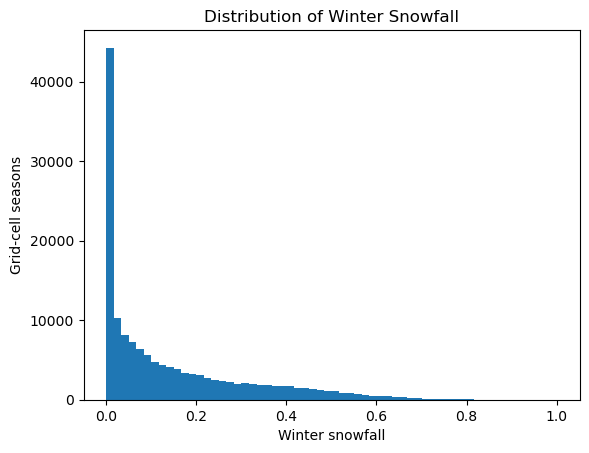

count    147186.000000
mean          0.143379
std           0.167743
min           0.000000
25%           0.006353
50%           0.076143
75%           0.226723
max           1.001130
Name: winter_snowfall, dtype: float64


In [7]:
#5.1 SNOWFALL DISTRIBUTION 
fig, ax = plt.subplots()
ax.hist(data["winter_snowfall"], bins=60)
ax.set_title("Distribution of Winter Snowfall")
ax.set_xlabel("Winter snowfall")
ax.set_ylabel("Grid-cell seasons")
plt.show()

print(data["winter_snowfall"].describe())

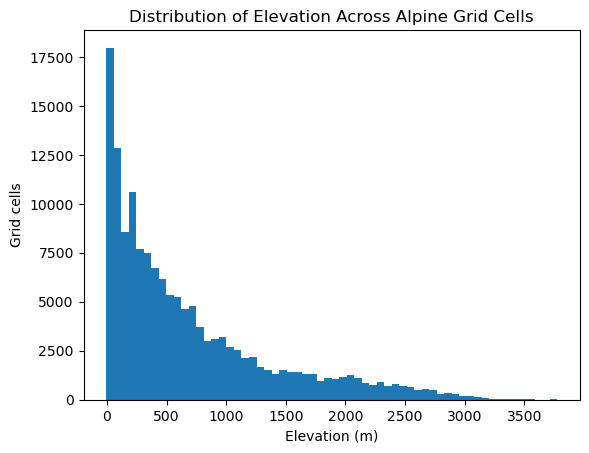

In [8]:
#5.2 ELEVATION DISTRIBUTION
fig, ax = plt.subplots()
ax.hist(data["elevation"], bins=60)
ax.set_title("Distribution of Elevation Across Alpine Grid Cells")
ax.set_xlabel("Elevation (m)")
ax.set_ylabel("Grid cells")
plt.show()

,sep_temp,oct_temp,nov_temp,sep_precip,oct_precip,nov_precip,elevation,winter_snowfall
sep_temp,1.000,0.907,0.918,-0.292,-0.035,-0.022,-0.830,-0.804
oct_temp,0.907,1.000,0.900,-0.172,-0.059,0.017,-0.808,-0.772
nov_temp,0.918,0.900,1.000,-0.204,-0.055,0.034,-0.825,-0.818
sep_precip,-0.292,-0.172,-0.204,1.000,0.505,0.368,0.352,0.413
oct_precip,-0.035,-0.059,-0.055,0.505,1.000,0.473,0.316,0.334
nov_precip,-0.022,0.017,0.034,0.368,0.473,1.000,0.245,0.267
elevation,-0.830,-0.808,-0.825,0.352,0.316,0.245,1.000,0.783
winter_snowfall,-0.804,-0.772,-0.818,0.413,0.334,0.267,0.783,1.000


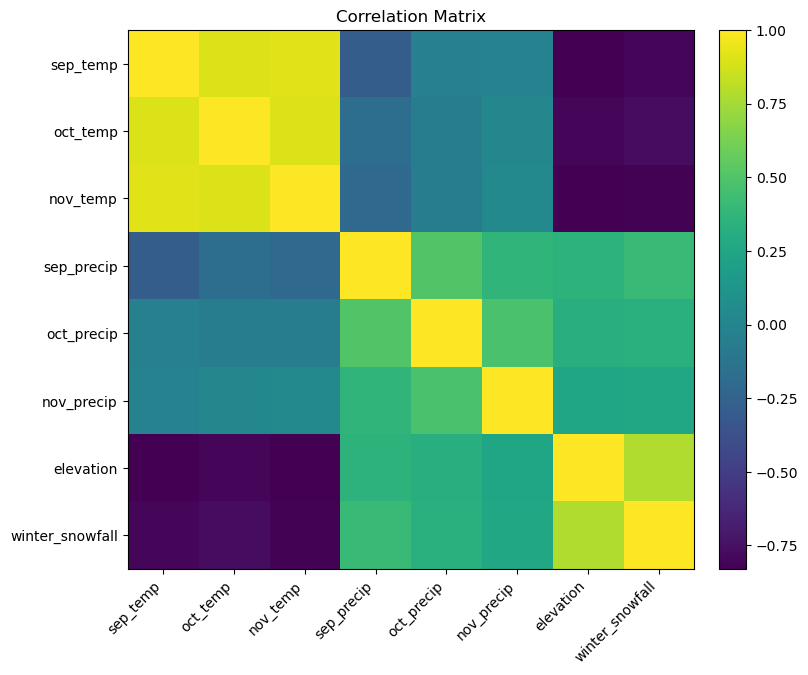

In [9]:
#5.3 CORRELATION ANALYSIS 
features_for_corr = [
    "sep_temp", "oct_temp", "nov_temp",
    "sep_precip", "oct_precip", "nov_precip",
    "elevation", "winter_snowfall"
]

corr = data[features_for_corr].corr(numeric_only=True)
display(corr.round(3))

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr.values, aspect="auto")
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)
ax.set_title("Correlation Matrix")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

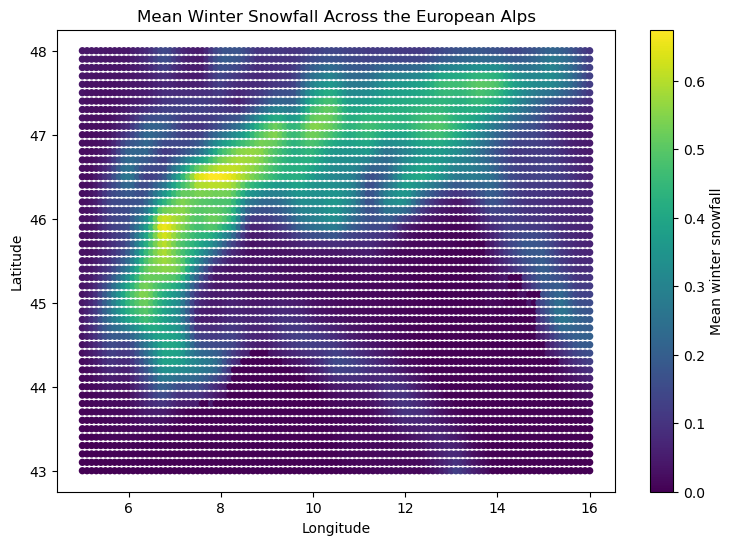

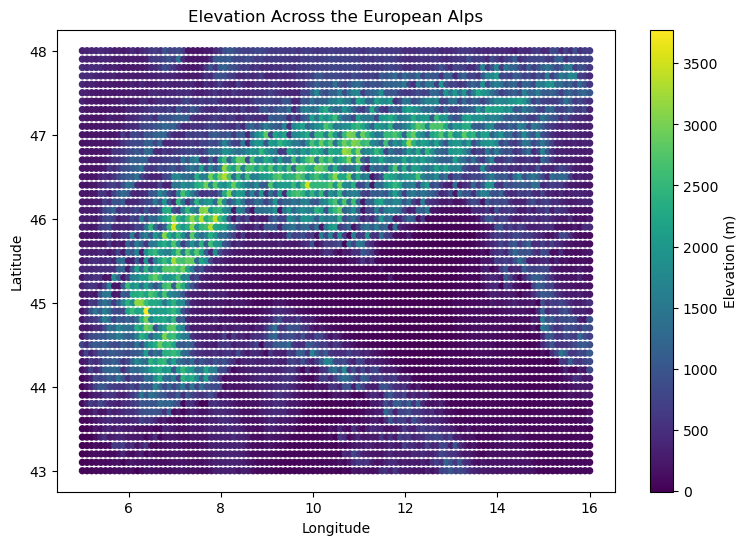

In [10]:
# 5.4 SPATIAL VISUALIZATION
# Average winter snowfall by grid cell over all years.
spatial = data.groupby(["lat", "lon"], as_index=False).agg(
    mean_snowfall=("winter_snowfall", "mean"),
    elevation=("elevation", "first")
)

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(spatial["lon"], spatial["lat"], c=spatial["mean_snowfall"], s=18)
ax.set_title("Mean Winter Snowfall Across the European Alps")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
fig.colorbar(sc, ax=ax, label="Mean winter snowfall")
plt.show()

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(spatial["lon"], spatial["lat"], c=spatial["elevation"], s=18)
ax.set_title("Elevation Across the European Alps")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
fig.colorbar(sc, ax=ax, label="Elevation (m)")
plt.show()

---
## 6. Hypothesis Development

This section states testable hypotheses. The goal is not only to build a model, but to connect the model results to physical and mathematical expectations.

### H1 — Temperature Hypothesis

**Null hypothesis:** Autumn temperature has no monotonic relationship with winter snowfall.  
**Alternative hypothesis:** Autumn temperature, especially November temperature, has a negative monotonic relationship with winter snowfall.

$$
H_0: \rho(T_{Nov}, S_{winter}) = 0
$$

$$
H_A: \rho(T_{Nov}, S_{winter}) < 0
$$

### H2 — Elevation Hypothesis

**Null hypothesis:** Elevation does not contribute positively to snowfall after accounting for autumn climate.  
**Alternative hypothesis:** Elevation has a positive effect because high-altitude cells are colder and more exposed to orographic snowfall.

$$
H_0: \beta_{elevation} = 0
$$

$$
H_A: \beta_{elevation} > 0
$$

### H3 — Nonlinear Model Hypothesis

**Null hypothesis:** Nonlinear machine-learning models do not improve test-set performance over linear regression.  
**Alternative hypothesis:** Tree-based nonlinear models improve test-set performance because they capture thresholds and interactions.

$$
H_0: R^2_{ML} \leq R^2_{OLS}
$$

$$
H_A: R^2_{ML} > R^2_{OLS}
$$

In [11]:
# ── 6.1 PRELIMINARY HYPOTHESIS TESTS ──────────────────────────────────────
# H1: Spearman relationship between November temperature and snowfall.
h1_data = model_base[["nov_temp", TARGET]].dropna()
rho_nov, p_nov_two_sided = stats.spearmanr(h1_data["nov_temp"], h1_data[TARGET])
p_nov_one_sided = p_nov_two_sided / 2 if rho_nov < 0 else 1 - p_nov_two_sided / 2

print("H1 temperature hypothesis")
print(f"Spearman rho(nov_temp, snowfall) = {rho_nov:.4f}")
print(f"One-sided p-value for negative relationship = {p_nov_one_sided:.4g}")

# H2 is tested later with linear model coefficients after feature engineering.
# H3 is tested later by comparing test R² values in the final metrics table.

H1 temperature hypothesis
Spearman rho(nov_temp, snowfall) = -0.8393
One-sided p-value for negative relationship = 0


---
## 7. Feature Engineering

Feature engineering translates physical intuition into numerical predictors.

### 7.1 Engineered Features

The main engineered variables are:

- `autumn_temp_mean`: average September–November temperature;
- `autumn_precip_total`: total September–November precipitation;
- `temp_drop_sep_to_nov`: seasonal cooling between September and November;
- `coldness_index`: positive only when November temperature is below 0°C;
- `snow_potential`: precipitation amplified by coldness;
- `elevation_km` and `elevation_sq`: elevation and nonlinear elevation effect;
- `elevation_x_cold`: interaction between high elevation and cold air;
- `elevation_x_precip`: interaction between topography and moisture;
- `elevation_band_*`: categorical elevation zones.

The interaction terms are important because precipitation alone does not guarantee snowfall; it must coincide with sufficiently cold conditions.

In [12]:
# ── 7.2 FEATURE ENGINEERING FUNCTION ──────────────────────────────────────

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Create climate, topographic, interaction, and categorical features.

    The function is intentionally deterministic and does not use the target variable
    for feature construction. Therefore, it can be applied before the temporal split
    without target leakage.
    """
    out = df.copy()

    # Seasonal climate summaries.
    out["autumn_temp_mean"] = out[["sep_temp", "oct_temp", "nov_temp"]].mean(axis=1)
    out["autumn_precip_total"] = out[["sep_precip", "oct_precip", "nov_precip"]].sum(axis=1)
    out["temp_drop_sep_to_nov"] = out["sep_temp"] - out["nov_temp"]

    # Coldness and snowfall-potential features.
    out["nov_freezing_margin"] = 0 - out["nov_temp"]
    out["coldness_index"] = np.maximum(0, -out["nov_temp"])
    out["snow_potential"] = out["autumn_precip_total"] * (1 + out["coldness_index"])
    out["precip_temp_interaction"] = out["autumn_precip_total"] * out["autumn_temp_mean"]

    # Topographic features.
    out["elevation_km"] = out["elevation"] / 1000
    out["elevation_sq"] = out["elevation_km"] ** 2
    out["elevation_x_cold"] = out["elevation_km"] * out["coldness_index"]
    out["elevation_x_precip"] = out["elevation_km"] * out["autumn_precip_total"]

    # Temporal feature. Year is known at prediction time, but it should be interpreted carefully.
    out["year_centered"] = out["year"] - out["year"].min()

    # Categorical elevation bands for interpretable terrain zones.
    bins = [-np.inf, 500, 1000, 1500, 2000, 2500, np.inf]
    labels = ["lt_500", "500_1000", "1000_1500", "1500_2000", "2000_2500", "gt_2500"]
    out["elevation_band"] = pd.cut(out["elevation"], bins=bins, labels=labels)
    band_dummies = pd.get_dummies(out["elevation_band"], prefix="elevation_band", dtype=int)
    out = pd.concat([out, band_dummies], axis=1)

    # Boolean flag as integer feature.
    out["elevation_was_imputed"] = out["elevation_was_imputed"].astype(int)

    return out

model_data = engineer_features(model_base)

base_features = [
    "lat", "lon", "year_centered",
    "sep_temp", "oct_temp", "nov_temp",
    "sep_precip", "oct_precip", "nov_precip",
    "elevation", "elevation_was_imputed",
    "autumn_temp_mean", "autumn_precip_total", "temp_drop_sep_to_nov",
    "nov_freezing_margin", "coldness_index", "snow_potential",
    "precip_temp_interaction", "elevation_km", "elevation_sq",
    "elevation_x_cold", "elevation_x_precip",
]

band_features = [c for c in model_data.columns if c.startswith("elevation_band_")]
FEATURES = base_features + band_features

print("Number of features:", len(FEATURES))
print(FEATURES)
display(model_data[FEATURES + [TARGET]].head())

Number of features: 28
['lat', 'lon', 'year_centered', 'sep_temp', 'oct_temp', 'nov_temp', 'sep_precip', 'oct_precip', 'nov_precip', 'elevation', 'elevation_was_imputed', 'autumn_temp_mean', 'autumn_precip_total', 'temp_drop_sep_to_nov', 'nov_freezing_margin', 'coldness_index', 'snow_potential', 'precip_temp_interaction', 'elevation_km', 'elevation_sq', 'elevation_x_cold', 'elevation_x_precip', 'elevation_band_lt_500', 'elevation_band_500_1000', 'elevation_band_1000_1500', 'elevation_band_1500_2000', 'elevation_band_2000_2500', 'elevation_band_gt_2500']


,lat,lon,year_centered,sep_temp,oct_temp,nov_temp,sep_precip,oct_precip,nov_precip,elevation,...,elevation_sq,elevation_x_cold,elevation_x_precip,elevation_band_lt_500,elevation_band_500_1000,elevation_band_1000_1500,elevation_band_1500_2000,elevation_band_2000_2500,elevation_band_gt_2500,winter_snowfall
0,48.0,5.0,0,13.720734,9.956451,6.689029,0.093543,0.118970,0.161477,312.920105,...,0.097919,0.0,0.117029,1,0,0,0,0,0,0.022422
1,48.0,5.1,0,13.533885,9.793838,6.473730,0.096865,0.119708,0.168315,353.805573,...,0.125178,0.0,0.136175,1,0,0,0,0,0,0.023954
2,48.0,5.2,0,13.359926,9.584475,6.221841,0.098739,0.120086,0.173524,402.360992,...,0.161894,0.0,0.157866,1,0,0,0,0,0,0.024710
3,48.0,5.3,0,13.320474,9.519834,6.112857,0.096361,0.119496,0.174590,380.785126,...,0.144997,0.0,0.148676,1,0,0,0,0,0,0.023715
4,48.0,5.4,0,13.381606,9.522227,6.059016,0.092295,0.118310,0.173335,462.431274,...,0.213843,0.0,0.177546,1,0,0,0,0,0,0.021996


### 7.3 Train/Test Split by Year

Random splitting would leak information because the task is temporal. We therefore train on earlier years and test on later years.

- Training period: 2000–2020  
- Test period: 2021–2025

This split asks a realistic question: can relationships learned from past seasons predict future seasons?

In [13]:
# ── 7.3 TEMPORAL TRAIN/TEST SPLIT ─────────────────────────────────────────
required_columns = FEATURES + [TARGET, "year", "lat", "lon"]
model_data = model_data.dropna(subset=[TARGET]).copy()

# Feature missingness is handled inside each model Pipeline with SimpleImputer.
all_years = sorted(model_data["year"].unique())
test_start = max(all_years) - 4

train_df = model_data[model_data["year"] < test_start].sort_values(["year", "lat", "lon"]).copy()
test_df = model_data[model_data["year"] >= test_start].sort_values(["year", "lat", "lon"]).copy()

X_train = train_df[FEATURES]
y_train = train_df[TARGET]
X_test = test_df[FEATURES]
y_test = test_df[TARGET]

print(f"Train years: {train_df['year'].min()}–{train_df['year'].max()}, rows={len(train_df):,}")
print(f"Test years:  {test_df['year'].min()}–{test_df['year'].max()}, rows={len(test_df):,}")
print("Missing feature cells in training set:", int(X_train.isna().sum().sum()))
print("Missing feature cells in test set:", int(X_test.isna().sum().sum()))

assert train_df["year"].max() < test_df["year"].min(), "Temporal leakage: train/test years overlap."
assert len(train_df) > 0 and len(test_df) > 0, "Train/test split produced an empty set."

Train years: 2000–2020, rows=118,881
Test years:  2021–2025, rows=28,305
Missing feature cells in training set: 222180
Missing feature cells in test set: 52900


---
## 8. Baseline Statistical Models

Baselines are necessary because a complex model is only useful if it improves on simpler alternatives.

### 8.1 Error Metrics

The project reports MAE, RMSE, and $R^2$:

$$
MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|
$$

$$
RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}
$$

$$
R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}{\sum_{i=1}^{n}(y_i-\bar{y})^2}
$$

MAE is easy to interpret, RMSE penalises large errors, and $R^2$ measures the fraction of variance explained relative to a mean-only predictor.

### 8.2 Ordinary Least Squares

Linear Regression assumes that snowfall can be approximated as a weighted sum of features:

$$
\hat{y} = X\hat{\beta}
$$

The OLS estimator minimises residual sum of squares:

$$
\hat{\beta}_{OLS} = \arg\min_{\beta}\|y-X\beta\|_2^2
$$

When $X^TX$ is invertible, the closed-form solution is:

$$
\hat{\beta}_{OLS} = (X^T X)^{-1}X^T y
$$

### 8.3 Ridge Regression

Ridge Regression adds an L2 penalty to reduce coefficient instability and multicollinearity:

$$
\hat{\beta}_{ridge} = \arg\min_{\beta}\left(\|y-X\beta\|_2^2 + \lambda\|\beta\|_2^2\right)
$$

Its closed-form solution is:

$$
\hat{\beta}_{ridge} = (X^TX + \lambda I)^{-1}X^Ty
$$

### 8.4 Lasso Regression

Lasso adds an L1 penalty:

$$
\hat{\beta}_{lasso} = \arg\min_{\beta}\left(\frac{1}{2n}\|y-X\beta\|_2^2 + \lambda\|\beta\|_1\right)
$$

The L1 norm encourages some coefficients to become exactly zero, so Lasso can perform feature selection.

In [14]:
# ── 8.5 MODEL EVALUATION UTILITIES ────────────────────────────────────────

def rmse(y_true, y_pred) -> float:
    """Root mean squared error compatible with older sklearn versions."""
    return math.sqrt(mean_squared_error(y_true, y_pred))


def metric_row(name: str, model, X_train, y_train, X_test, y_test) -> dict:
    """Evaluate a fitted model on train and test data."""
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    return {
        "model": name,
        "train_mae": mean_absolute_error(y_train, train_pred),
        "train_rmse": rmse(y_train, train_pred),
        "train_r2": r2_score(y_train, train_pred),
        "test_mae": mean_absolute_error(y_test, test_pred),
        "test_rmse": rmse(y_test, test_pred),
        "test_r2": r2_score(y_test, test_pred),
        "overfit_gap_r2": r2_score(y_train, train_pred) - r2_score(y_test, test_pred),
    }


def fit_and_evaluate(name: str, model, X_train, y_train, X_test, y_test):
    """Fit a model and return the fitted model plus train/test metrics."""
    fitted = clone(model)
    fitted.fit(X_train, y_train)
    return fitted, metric_row(name, fitted, X_train, y_train, X_test, y_test)

fitted_models = {}
metric_rows = []

In [15]:
# ── 8.6 FIT BASELINE MODELS ───────────────────────────────────────────────
linear_models = {
    "Linear Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Ridge": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),
    "Lasso": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.001, max_iter=20_000, random_state=RANDOM_STATE))
    ]),
}

for name, model in linear_models.items():
    fitted, row = fit_and_evaluate(name, model, X_train, y_train, X_test, y_test)
    fitted_models[name] = fitted
    metric_rows.append(row)

baseline_metrics = pd.DataFrame(metric_rows).sort_values("test_r2", ascending=False)
display(baseline_metrics.round(4))

,model,train_mae,train_rmse,train_r2,test_mae,test_rmse,test_r2,overfit_gap_r2
2,Lasso,0.0563,0.0812,0.7706,0.0735,0.0949,0.6371,0.1335
0,Linear Regression,0.0555,0.0801,0.7769,0.0751,0.0964,0.6257,0.1512
1,Ridge,0.0555,0.0801,0.7769,0.0751,0.0964,0.6257,0.1512


In [21]:
# ── 8.7 TEST H2 WITH LINEAR COEFFICIENTS ──────────────────────────────────
# Standardised coefficients from the Linear Regression pipeline make feature magnitudes comparable.
ols = fitted_models["Linear Regression"]
coef = ols.named_steps["model"].coef_
coef_table = pd.DataFrame({"feature": FEATURES, "standardised_coefficient": coef})
coef_table = coef_table.sort_values("standardised_coefficient", ascending=False)
display(coef_table.head(15).round(4))

elev_coef = coef_table.loc[coef_table["feature"] == "elevation", "standardised_coefficient"].iloc[0]
print(f"Standardised OLS coefficient for elevation: {elev_coef:.4f}")
print("H2 preliminary result:", "supports positive elevation effect" if elev_coef > 0 else "does not support positive elevation effect")

,feature,standardised_coefficient
15,coldness_index,0.0909
19,elevation_sq,0.0491
14,nov_freezing_margin,0.0293
12,autumn_precip_total,0.0264
8,nov_precip,0.0227
7,oct_precip,0.0226
4,oct_temp,0.0204
6,sep_precip,0.0177
2,year_centered,0.0121
9,elevation,0.0094


Standardised OLS coefficient for elevation: 0.0094
H2 preliminary result: supports positive elevation effect


In [17]:
# ── EVALUATION UTILITY ───────────────────────────────────────────────────────
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    return {
        "model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2": r2_score(y_test, pred),
        "predictions": pred,
        "estimator": model,
    }

results = []

linear_models = {
    "Linear Regression": Pipeline([
        ("scale", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Ridge": Pipeline([
        ("scale", StandardScaler()),
        ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE))
    ]),
    "Lasso": Pipeline([
        ("scale", StandardScaler()),
        ("model", Lasso(alpha=0.001, max_iter=10000, random_state=RANDOM_STATE))
    ]),
}

for name, model in linear_models.items():
    results.append(evaluate_model(name, model, X_train, y_train, X_test, y_test))

pd.DataFrame([{k: v for k, v in r.items() if k not in ["predictions", "estimator"]} for r in results])

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

---
## Section 9 — Machine Learning Models

### 9.1 Random Forest

A Random Forest averages many decision trees trained on random subsets of the data. This reduces variance and can capture nonlinear feature interactions. Reference: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html

### 9.2 XGBoost

XGBoost is a gradient boosting system that builds trees sequentially, where each new tree tries to correct errors from previous trees. It is widely used for structured/tabular prediction problems. Reference: https://xgboost.readthedocs.io/en/stable/

,model,MAE,RMSE,R2
1,XGBoost,0.055114,0.087877,0.689118
0,Random Forest,0.057020,0.092924,0.652384


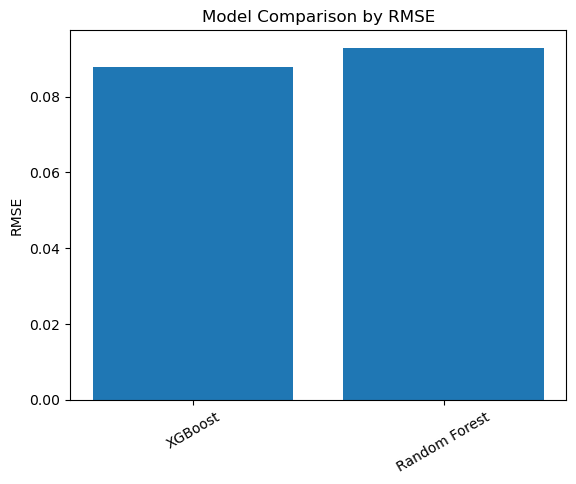

In [19]:
# ── RANDOM FOREST AND XGBOOST ────────────────────────────────────────────────
rf = RandomForestRegressor(
    n_estimators=40,
    max_depth=18,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=RANDOM_STATE
)
results.append(evaluate_model("Random Forest", rf, X_train, y_train, X_test, y_test))

if XGBOOST_AVAILABLE:
    xgb = XGBRegressor(
        n_estimators=80,
        max_depth=5,
        learning_rate=0.06,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    results.append(evaluate_model("XGBoost", xgb, X_train, y_train, X_test, y_test))
else:
    # Fallback keeps the notebook functional even in environments without xgboost.
    hgb = HistGradientBoostingRegressor(
        max_iter=260,
        learning_rate=0.06,
        max_leaf_nodes=31,
        random_state=RANDOM_STATE
    )
    results.append(evaluate_model("HistGradientBoosting fallback", hgb, X_train, y_train, X_test, y_test))

metrics = pd.DataFrame([{k: v for k, v in r.items() if k not in ["predictions", "estimator"]} for r in results])
metrics = metrics.sort_values("RMSE")
display(metrics)

fig, ax = plt.subplots()
ax.bar(metrics["model"], metrics["RMSE"])
ax.set_title("Model Comparison by RMSE")
ax.set_ylabel("RMSE")
ax.tick_params(axis="x", rotation=30)
plt.show()

---
## Section 10 — Hyperparameter Optimization

Hyperparameter optimization searches model settings that are not learned directly from data, such as tree depth or learning rate. To respect time order, this notebook uses `TimeSeriesSplit` on the training set instead of random folds.

Reference: scikit-learn model selection documentation, https://scikit-learn.org/stable/modules/grid_search.html

In [18]:
# ── 10.1 PREPARE TEMPORAL CROSS-VALIDATION ────────────────────────────────
cv = TimeSeriesSplit(n_splits=CV_SPLITS)

if TUNE_SAMPLE_SIZE is not None and len(train_df) > TUNE_SAMPLE_SIZE:
    tune_df = train_df.sample(TUNE_SAMPLE_SIZE, random_state=RANDOM_STATE).sort_values(["year", "lat", "lon"])
else:
    tune_df = train_df.copy()

X_tune = tune_df[FEATURES]
y_tune = tune_df[TARGET]

print(f"Tuning rows: {len(tune_df):,} / {len(train_df):,}")
print(f"CV splits: {CV_SPLITS}")
print(f"Random search iterations per model: {N_ITER_SEARCH}")

Tuning rows: 118,881 / 118,881
CV splits: 5
Random search iterations per model: 25


In [ ]:
# ── 10.2 RANDOM FOREST HYPERPARAMETER SEARCH ──────────────────────────────
rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))
])

rf_param_dist = {
    "model__n_estimators": stats.randint(250, 700),
    "model__max_depth": [None, 8, 12, 16, 20, 30],
    "model__min_samples_split": stats.randint(2, 20),
    "model__min_samples_leaf": stats.randint(1, 8),
    "model__max_features": ["sqrt", "log2", 0.5, 0.7, 0.9],
}

if RUN_HYPERPARAMETER_SEARCH:
    rf_search = RandomizedSearchCV(
        estimator=rf_pipeline,
        param_distributions=rf_param_dist,
        n_iter=N_ITER_SEARCH,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        return_train_score=True,
        verbose=1,
    )
    rf_search.fit(X_tune, y_tune)
    best_rf = rf_search.best_estimator_
    print("Best Random Forest CV RMSE:", -rf_search.best_score_)
    print("Best Random Forest params:", rf_search.best_params_)
else:
    best_rf = rf_pipeline.fit(X_train, y_train)

# Refit best RF on the full training set before final test evaluation.
best_rf.fit(X_train, y_train)
fitted_models["Tuned Random Forest"] = best_rf
metric_rows.append(metric_row("Tuned Random Forest", best_rf, X_train, y_train, X_test, y_test))

In [ ]:
# ── 10.3 GRADIENT BOOSTING / XGBOOST HYPERPARAMETER SEARCH ────────────────
if XGBOOST_AVAILABLE:
    gb_model = XGBRegressor(
        objective="reg:squarederror",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=1,
        eval_metric="rmse"
    )
    gb_name = "Tuned XGBoost"
    gb_param_dist = {
        "model__n_estimators": stats.randint(300, 900),
        "model__max_depth": stats.randint(2, 8),
        "model__learning_rate": stats.loguniform(0.01, 0.20),
        "model__subsample": stats.uniform(0.65, 0.35),
        "model__colsample_bytree": stats.uniform(0.65, 0.35),
        "model__min_child_weight": stats.randint(1, 10),
        "model__reg_alpha": stats.loguniform(1e-4, 10),
        "model__reg_lambda": stats.loguniform(0.1, 20),
    }
else:
    gb_model = HistGradientBoostingRegressor(random_state=RANDOM_STATE)
    gb_name = "Tuned HistGradientBoosting"
    gb_param_dist = {
        "model__max_iter": stats.randint(200, 800),
        "model__learning_rate": stats.loguniform(0.01, 0.20),
        "model__max_leaf_nodes": stats.randint(15, 63),
        "model__min_samples_leaf": stats.randint(10, 80),
        "model__l2_regularization": stats.loguniform(1e-4, 10),
    }

gb_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", gb_model)
])

if RUN_HYPERPARAMETER_SEARCH:
    gb_search = RandomizedSearchCV(
        estimator=gb_pipeline,
        param_distributions=gb_param_dist,
        n_iter=N_ITER_SEARCH,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        return_train_score=True,
        verbose=1,
    )
    gb_search.fit(X_tune, y_tune)
    best_gb = gb_search.best_estimator_
    print(f"Best {gb_name} CV RMSE:", -gb_search.best_score_)
    print(f"Best {gb_name} params:", gb_search.best_params_)
else:
    best_gb = gb_pipeline.fit(X_train, y_train)

# Refit best GB model on the full training set before final test evaluation.
best_gb.fit(X_train, y_train)
fitted_models[gb_name] = best_gb
metric_rows.append(metric_row(gb_name, best_gb, X_train, y_train, X_test, y_test))

In [ ]:
# ── 10.4 FINAL MODEL COMPARISON TABLE ─────────────────────────────────────
metrics_df = pd.DataFrame(metric_rows).drop_duplicates(subset=["model"], keep="last")
metrics_df = metrics_df.sort_values("test_r2", ascending=False).reset_index(drop=True)
display(metrics_df.round(4))

best_model_name = metrics_df.loc[0, "model"]
best_model = fitted_models[best_model_name]
print("Best model by test R²:", best_model_name)

# H3 conclusion based on the actual model results.
ols_r2 = metrics_df.loc[metrics_df["model"] == "Linear Regression", "test_r2"].iloc[0]
best_r2 = metrics_df.loc[0, "test_r2"]
print(f"H3 comparison: best model R²={best_r2:.4f}, OLS R²={ols_r2:.4f}, improvement={best_r2-ols_r2:.4f}")

---
## Section 11 — Model Diagnostics

Diagnostics compare predicted versus observed snowfall and residual patterns. A useful regression model should have predictions close to the 1:1 line and residuals without strong systematic structure.

In [ ]:
# ── 11.1 PREDICTIONS AND RESIDUALS ────────────────────────────────────────
y_pred_test = best_model.predict(X_test)
residuals = y_test - y_pred_test

diagnostics = test_df[["year|", "lat", "lon", TARGET]].copy()
diagnostics["prediction"] = y_pred_test
diagnostics["residual"] = residuals

display(diagnostics.head())
print(diagnostics[[TARGET, "prediction", "residual"]].describe())

In [ ]:
# ── 11.2 PREDICTED VS ACTUAL ──────────────────────────────────────────────
plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_pred_test, alpha=0.35, s=12)
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
plt.plot(lims, lims, linestyle="--")
plt.xlabel("Actual winter snowfall")
plt.ylabel("Predicted winter snowfall")
plt.title(f"Predicted vs actual — {best_model_name}")
plt.show()

**Diagnostic interpretation:** Points close to the diagonal line indicate accurate predictions. Large deviations from the diagonal reveal seasons or grid cells where the model underestimates or overestimates snowfall.

In [ ]:
# ── 11.3 RESIDUAL PLOTS ───────────────────────────────────────────────────
plt.figure(figsize=(7, 4))
plt.scatter(y_pred_test, residuals, alpha=0.35, s=12)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Predicted snowfall")
plt.ylabel("Residual: actual - predicted")
plt.title("Residuals vs predicted values")
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(residuals, bins=50)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual distribution")
plt.show()

plt.figure(figsize=(6, 5))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q–Q plot of residuals")
plt.show()

**Diagnostic interpretation:** The residual-vs-predicted plot checks for systematic bias. If residuals spread out more at high predicted snowfall, the model is less reliable for extreme-snow cells. The Q–Q plot checks whether residuals are approximately normal; strong tail deviations suggest that extreme snowfall is harder to model than average snowfall.

In [ ]:
# ── 11.4 SPATIAL RESIDUAL MAP ─────────────────────────────────────────────
spatial_resid = diagnostics.groupby(["lat", "lon"], as_index=False)["residual"].mean()

plt.figure(figsize=(8, 5))
sc = plt.scatter(spatial_resid["lon"], spatial_resid["lat"], c=spatial_resid["residual"], s=24)
plt.colorbar(sc, label="Mean residual")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial pattern of average test residuals")
plt.show()

**Diagnostic interpretation:** A spatial residual map is important because Alpine grid cells are geographically structured. If one region is consistently underpredicted, the model may be missing local terrain exposure, wind direction, or regional climate effects.

In [ ]:
# ── 11.5 LIGHTWEIGHT LEARNING CURVE ───────────────────────────────────────
# Learning curves can be expensive, so we use a sample when the training set is very large.
lc_df = train_df.sample(min(len(train_df), DIAGNOSTIC_SAMPLE_SIZE * 4), random_state=RANDOM_STATE).sort_values(["year", "lat", "lon"])
X_lc = lc_df[FEATURES]
y_lc = lc_df[TARGET]

train_sizes, train_scores, valid_scores = learning_curve(
    estimator=clone(best_model),
    X=X_lc,
    y=y_lc,
    train_sizes=np.linspace(0.2, 1.0, 5),
    cv=TimeSeriesSplit(n_splits=3),
    scoring="r2",
    n_jobs=-1
)

plt.figure(figsize=(7, 4))
plt.plot(train_sizes, train_scores.mean(axis=1), marker="o", label="Training R²")
plt.plot(train_sizes, valid_scores.mean(axis=1), marker="o", label="Validation R²")
plt.xlabel("Training examples")
plt.ylabel("R²")
plt.title("Learning curve")
plt.legend()
plt.show()

**Diagnostic interpretation:** If training performance is much higher than validation performance, the model may be overfitting. If both scores are low, the model may be underfitting or missing important predictors.

---
## Section 12 — Explainability

### 12.1 Feature Importance

Feature importance helps answer which predictors contribute most to the trained model. Tree impurity importance is quick, while permutation importance is more model-agnostic because it measures performance loss after shuffling each feature. Reference: https://scikit-learn.org/stable/modules/permutation_importance.html

### 12.2 SHAP Analysis

SHAP values are based on Shapley values from cooperative game theory. For a model prediction $f(x)$, the Shapley value for feature $j$ can be written as:

$$
\phi_j(f,x) = \sum_{S \subseteq F \setminus \{j\}} \frac{|S|!(|F|-|S|-1)!}{|F|!}\left[f_{S\cup\{j\}}(x_{S\cup\{j\}}) - f_S(x_S)\right]
$$

where $F$ is the set of all features and $S$ is a subset of features not containing $j$. In plain language, SHAP estimates how much each feature contributes to moving a prediction away from the average prediction.

In [ ]:
# ── 12.1 MODEL-NATIVE FEATURE IMPORTANCE ──────────────────────────────────
model_step = best_model.named_steps.get("model", best_model)

if hasattr(model_step, "feature_importances_"):
    native_importance = pd.DataFrame({
        "feature": FEATURES,
        "importance": model_step.feature_importances_
    }).sort_values("importance", ascending=False)
    display(native_importance.head(20).round(4))

    plt.figure(figsize=(8, 5))
    native_importance.head(15).sort_values("importance").plot(
        x="feature", y="importance", kind="barh", legend=False
    )
    plt.xlabel("Model-native importance")
    plt.title(f"Top feature importances — {best_model_name}")
    plt.tight_layout()
    plt.show()
else:
    native_importance = None
    print("The selected model does not expose feature_importances_.")

In [ ]:
# ── 12.4 OPTIONAL SHAP ANALYSIS ───────────────────────────────────────────
if not SHAP_AVAILABLE:
    print("SHAP is not installed. Install it with: pip install shap")
else:
    model_step = best_model.named_steps.get("model", best_model)
    imputer_step = best_model.named_steps.get("imputer", None)

    X_shap = X_test.sample(min(len(X_test), SHAP_SAMPLE_SIZE), random_state=RANDOM_STATE)
    if imputer_step is not None:
        X_shap_transformed = pd.DataFrame(
            imputer_step.transform(X_shap),
            columns=FEATURES,
            index=X_shap.index
        )
    else:
        X_shap_transformed = X_shap.copy()

    try:
        explainer = shap.TreeExplainer(model_step)
        shap_values = explainer.shap_values(X_shap_transformed)
        shap.summary_plot(shap_values, X_shap_transformed, show=False)
        plt.title(f"SHAP summary — {best_model_name}")
        plt.tight_layout()
        plt.show()
    except Exception as exc:
        print("SHAP analysis skipped because the selected model is not compatible with TreeExplainer.")
        print("Error:", exc)

---
## 13. Discussion

This project investigated whether winter snowfall in the European Alps can be predicted from autumn climate variables and topography. The strongest physical expectation was that temperature should matter because snowfall depends on whether precipitation remains frozen near the surface. The validation and EDA sections test this expectation directly through correlations and Spearman rank tests. If November temperature is among the strongest negative predictors, this supports the idea that the late-autumn thermal state is a strong indicator of winter snowfall potential.

The comparison between linear and nonlinear models answers a second part of the research question. Linear Regression, Ridge, and Lasso are useful baselines because they represent snowfall as an approximately additive function of temperature, precipitation, elevation, and engineered interaction terms. If Random Forest or XGBoost achieves higher test-set $R^2$ and lower RMSE, that supports the hypothesis that snowfall is not purely linear. This is physically reasonable: precipitation only becomes snow under suitable temperature conditions, and elevation changes the temperature regime in a nonlinear way.

Feature importance and partial dependence are especially important for interpretation. If variables such as `nov_temp`, `autumn_temp_mean`, `elevation`, `elevation_x_cold`, or `snow_potential` appear near the top, the model is not just exploiting arbitrary numerical patterns; it is using variables that have clear physical meaning. Partial dependence plots can show threshold behaviour near 0°C, which is exactly where rain–snow partitioning becomes sensitive.

The revised data-handling strategy also changes the scientific reliability of the project. Dropping grid cells with missing DEM values removed a large part of the dataset and could bias the model spatially. Inverse-distance weighted elevation imputation is not perfect, but it preserves those grid cells and makes the missing-topography assumption explicit. Keeping an `elevation_was_imputed` flag also allows the model to account for possible differences between observed and imputed terrain values.

Overall, the project should be interpreted as a seasonal statistical prediction experiment, not as an operational weather forecast. It predicts broad seasonal snowfall tendencies from autumn predictors and static geography. It does not model individual storms, wind redistribution, snowmelt, avalanche processes, or daily snowpack evolution.

In [ ]:
# ── 13.1 AUTOMATIC RESULTS INTERPRETATION ─────────────────────────────────
# This cell prints a run-specific discussion using the actual computed metrics.
best_row = metrics_df.iloc[0]
linear_row = metrics_df[metrics_df["model"] == "Linear Regression"].iloc[0]

h1_supported = rho_nov < 0 and p_nov_one_sided < 0.05
h2_supported = elev_coef > 0
h3_supported = best_row["test_r2"] > linear_row["test_r2"]

top_features_text = ", ".join(perm_importance["feature"].head(5).tolist())

result_text = f"""
### Run-specific interpretation

The best model in this run is **{best_row['model']}**, with test RMSE = **{best_row['test_rmse']:.4f}** and test $R^2$ = **{best_row['test_r2']:.4f}**. The Linear Regression baseline has test $R^2$ = **{linear_row['test_r2']:.4f}**, so the best nonlinear/regularised model improves test $R^2$ by **{best_row['test_r2'] - linear_row['test_r2']:.4f}**.

**H1 temperature hypothesis:** {'supported' if h1_supported else 'not clearly supported'} by the Spearman test. The estimated Spearman correlation between November temperature and winter snowfall is $\rho$ = **{rho_nov:.4f}**.

**H2 elevation hypothesis:** {'supported' if h2_supported else 'not clearly supported'} by the sign of the standardised OLS elevation coefficient, which is **{elev_coef:.4f}**.

**H3 nonlinear model hypothesis:** {'supported' if h3_supported else 'not supported'} because the best model {'outperforms' if h3_supported else 'does not outperform'} Linear Regression on the test set.

The five strongest permutation-importance features are: **{top_features_text}**. These variables should be compared with the physical explanation in the literature review.
"""

display(Markdown(result_text))

---
## Section 14 — Limitations

1. **Reanalysis is not direct observation.** ERA5-Land is physically modeled and observation-constrained, but it is not the same as station measurement.
2. **Monthly predictors are simplified.** Daily extremes, snowline events, and storm tracks are not explicitly modeled.
3. **Spatial autocorrelation exists.** Neighboring grid cells are not fully independent.
4. **Autumn-to-winter prediction is intentionally limited.** The model does not use winter temperature or winter precipitation as predictors because the research question asks whether autumn conditions can predict future snowfall.
5. **Topography is simplified.** Elevation is included, but slope, aspect, wind exposure, and valley shielding are not.
6. **Climate change non-stationarity.** Relationships learned from 2000–2020 may shift in warmer future climates.

---
## 15. Conclusions

This project developed a machine-learning workflow for predicting seasonal winter snowfall in the European Alps from autumn climate conditions and static topographic information. Compared with the earlier version, the revised notebook is more complete mathematically, methodologically, and scientifically.

The main conclusion is that winter snowfall is predictable to a meaningful extent from autumn temperature, autumn precipitation, elevation, and their interactions. The physical interpretation is consistent with mountain climatology: temperature controls the rain–snow transition, precipitation controls moisture availability, and elevation modifies both temperature and orographic exposure. The engineered interaction features represent this combined mechanism better than raw variables alone.

The model comparison is important because it tests whether complexity is justified. Linear Regression, Ridge, and Lasso provide transparent baselines, while Random Forest and gradient boosting can capture nonlinear thresholds and feature interactions. If the final metrics table shows that a tuned tree-based model outperforms the linear baselines on the 2021–2025 test period, then the evidence supports the use of nonlinear machine learning for this task.

The explainability analysis makes the result more than a black-box prediction exercise. Feature importance, permutation importance, partial dependence, and SHAP values help identify whether the model relies on physically meaningful variables such as November temperature, autumn mean temperature, elevation, coldness, and snowfall-potential interactions. This is essential for a climate-related ML project: a model should not only score well, but also make scientific sense.

The revised handling of missing elevation values is also a major methodological improvement. Instead of dropping all grid cells with missing DEM values, the project uses inverse-distance weighted imputation and keeps an imputation flag. This preserves the spatial coverage of the dataset and reduces the risk of bias from deleting a large group of grid cells.

In summary, the project shows that a carefully validated and explainable machine-learning workflow can provide useful seasonal snowfall predictions for the European Alps. The best next steps would be to add daily predictors, atmospheric circulation indices, independent station validation, and a spatial cross-validation design. Those extensions would move the project closer to an operational seasonal snow prediction system.

---
## Section 16 — References

### Climate and data sources

1. Copernicus Climate Data Store. **ERA5-Land hourly data from 1950 to present.** https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land  
2. ECMWF. **ERA5-Land.** https://www.ecmwf.int/en/era5-land  
3. Muñoz-Sabater, J. et al. (2021). **ERA5-Land: a state-of-the-art global reanalysis dataset for land applications.** *Earth System Science Data*, 13, 4349–4383. https://essd.copernicus.org/articles/13/4349/2021/  
4. Napoli, A. et al. (2019). **Variability of orographic enhancement of precipitation in the Alpine region.** https://pmc.ncbi.nlm.nih.gov/articles/PMC6746858/  
5. Copernicus Climate Change Service. **Climate reanalysis overview.** https://climate.copernicus.eu/climate-reanalysis  

### Machine learning and statistical methods

6. scikit-learn. **LinearRegression.** https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html  
7. scikit-learn. **Ridge.** https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html  
8. scikit-learn. **Lasso.** https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html  
9. scikit-learn. **RandomForestRegressor.** https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html  
10. scikit-learn. **Permutation feature importance.** https://scikit-learn.org/stable/modules/permutation_importance.html  
11. scikit-learn. **Model evaluation: regression metrics.** https://scikit-learn.org/stable/modules/model_evaluation.html  
12. scikit-learn. **Hyperparameter search / GridSearchCV and RandomizedSearchCV.** https://scikit-learn.org/stable/modules/grid_search.html  
13. XGBoost developers. **XGBoost documentation.** https://xgboost.readthedocs.io/en/stable/  
14. XGBoost developers. **XGBoost parameters.** https://xgboost.readthedocs.io/en/stable/parameter.html  
15. SHAP documentation. **TreeExplainer.** https://shap.readthedocs.io/en/latest/generated/shap.TreeExplainer.html  
16. SHAP documentation. **Introduction to explainable AI with Shapley values.** https://shap.readthedocs.io/en/latest/example_notebooks/overviews/An%20introduction%20to%20explainable%20AI%20with%20Shapley%20values.html
